In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
census_path = Path("../data/raw/census/waterloo_da_bbox.geojson")

print(census_path.exists())

True


In [3]:
da = gpd.read_file(census_path)

In [4]:
da.shape

(1149, 5)

In [5]:
da.head()

,DAUID,DGUID,LANDAREA,PRUID,geometry
0,35230150,2021S051235230150,0.1275,35,"POLYGON ((-80.23436 43.54631, -80.23503 43.546..."
1,35230151,2021S051235230151,0.2474,35,"POLYGON ((-80.23566 43.54634, -80.23503 43.546..."
2,35230152,2021S051235230152,0.1780,35,"POLYGON ((-80.23513 43.54838, -80.23412 43.549..."
3,35230153,2021S051235230153,0.1919,35,"POLYGON ((-80.23997 43.55027, -80.2372 43.5525..."
4,35230154,2021S051235230154,0.2022,35,"POLYGON ((-80.24292 43.54779, -80.24277 43.547..."


In [6]:
da.columns

Index(['DAUID', 'DGUID', 'LANDAREA', 'PRUID', 'geometry'], dtype='str')

In [7]:
da.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1149 entries, 0 to 1148
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   DAUID     1149 non-null   str     
 1   DGUID     1149 non-null   str     
 2   LANDAREA  1149 non-null   float64 
 3   PRUID     1149 non-null   str     
 4   geometry  1149 non-null   geometry
dtypes: float64(1), geometry(1), str(3)
memory usage: 45.0 KB


In [8]:
da.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [9]:
da.geometry.geom_type.value_counts()

Polygon    1149
Name: count, dtype: int64

In [10]:
da["DAUID"].duplicated().sum()

np.int64(0)

In [11]:
da["PRUID"].value_counts()

PRUID
35    1149
Name: count, dtype: int64

In [12]:
boundary_path = Path(
    "../data/raw/boundaries/waterloo_municipal_boundaries.geojson"
)

municipalities = gpd.read_file(boundary_path)

print(municipalities.shape)
print(municipalities.crs)

(7, 4)
EPSG:4326


In [13]:
print("DA CRS:", da.crs)
print("Municipality CRS:", municipalities.crs)

DA CRS: EPSG:4326
Municipality CRS: EPSG:4326


In [14]:
waterloo_region = municipalities.geometry.union_all()

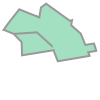

In [15]:
waterloo_region

In [16]:
waterloo_da = da[
    da.geometry.intersects(waterloo_region)
].copy()

In [17]:
print("DA records before filtering:", len(da))
print("DA records after filtering:", len(waterloo_da))

DA records before filtering: 1149
DA records after filtering: 791


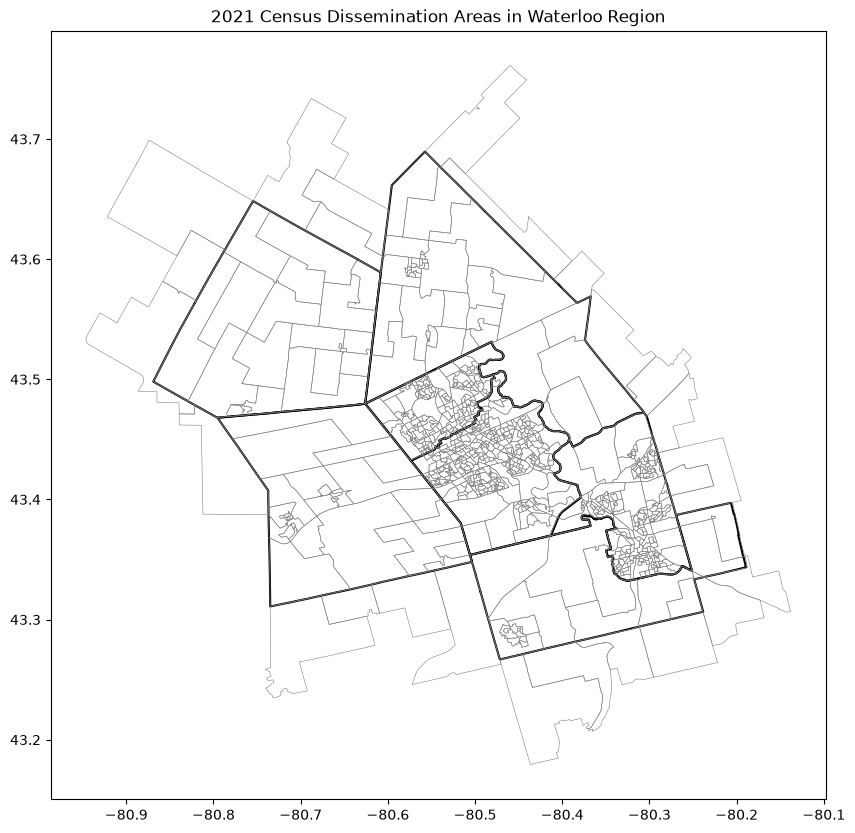

In [18]:
fig, ax = plt.subplots(figsize=(10, 10))

municipalities.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.5
)

waterloo_da.plot(
    ax=ax,
    facecolor="none",
    edgecolor="gray",
    linewidth=0.4
)

ax.set_title("2021 Census Dissemination Areas in Waterloo Region")
plt.show()

In [19]:
da_projected = da.to_crs("EPSG:26917")
municipalities_projected = municipalities.to_crs("EPSG:26917")

waterloo_region_projected = municipalities_projected.geometry.union_all()

In [20]:
print("DA CRS:", da_projected.crs)
print("Municipalities CRS:", municipalities_projected.crs)

DA CRS: EPSG:26917
Municipalities CRS: EPSG:26917


In [21]:
da_projected["representative_point"] = (
    da_projected.geometry.representative_point()
)

In [22]:
waterloo_da = da_projected[
    da_projected["representative_point"].within(
        waterloo_region_projected
    )
].copy()

In [23]:
print("DA records before filtering:", len(da_projected))
print("DA records after filtering:", len(waterloo_da))

DA records before filtering: 1149
DA records after filtering: 766


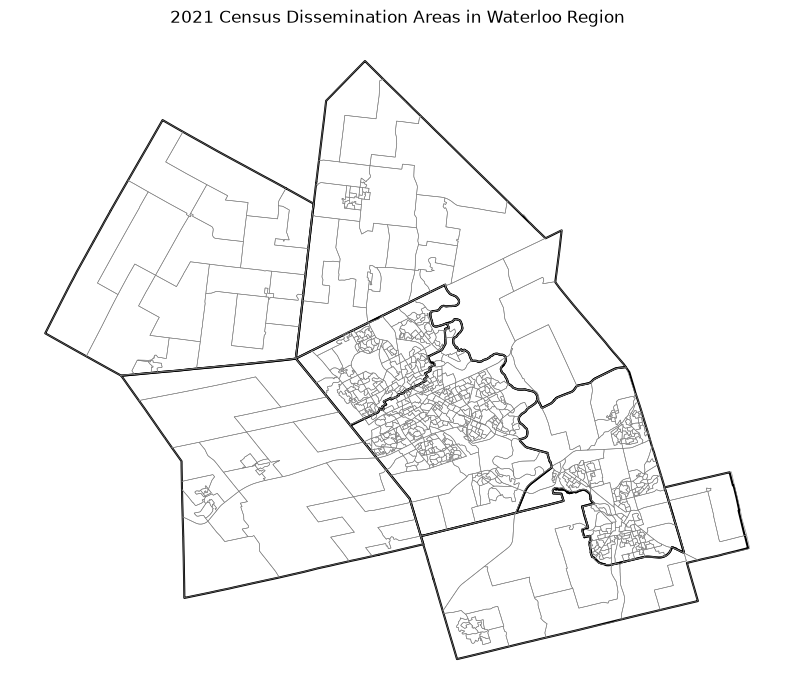

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))

municipalities_projected.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.5
)

waterloo_da.plot(
    ax=ax,
    facecolor="none",
    edgecolor="gray",
    linewidth=0.4
)

ax.set_title("2021 Census Dissemination Areas in Waterloo Region")
ax.set_axis_off()

plt.show()

In [25]:
waterloo_da[["DAUID"]].head(10)

,DAUID
271,35300742
272,35300743
273,35300744
274,35300745
275,35300746
276,35300296
277,35300297
278,35300298
279,35300329
280,35300330


In [26]:
print(waterloo_da["DAUID"].dtype)
print(waterloo_da["DAUID"].nunique())

str
766


In [27]:
population_path = Path("../data/raw/census/DA.csv")

print(population_path.exists())

True


In [28]:
da_population = pd.read_csv(
    population_path,
    dtype=str
)

In [29]:
da_population.shape

(57936, 21)

In [30]:
da_population.columns.tolist()

['DAuid',
 'DAdguid',
 'DApop_2021',
 'DAtdwell_2021',
 'DAurdwell_2021',
 'DAarea',
 'DAir_2021',
 'DArplamx',
 'DArplamy',
 'DArplat',
 'DArplong',
 'PRuid',
 'CDcode',
 'ADAcode',
 'DAcode',
 'ERcode',
 'CCScode',
 'CSDcode',
 'CMAuid',
 'CTname',
 'CTcode']

In [31]:
da_population.head()

,DAuid,DAdguid,DApop_2021,DAtdwell_2021,DAurdwell_2021,DAarea,DAir_2021,DArplamx,DArplamy,DArplat,...,PRuid,CDcode,ADAcode,DAcode,ERcode,CCScode,CSDcode,CMAuid,CTname,CTcode
0,10010165,2021S051210010165,500,229,217,0.3817,0,8978366.1629,2146133.5914,47.525069,...,10,01,0007,0165,10,519,519,001,0170.02,4738
1,10010166,2021S051210010166,340,165,146,0.0954,0,8978402.5281,2146467.5791,47.527321,...,10,01,0007,0166,10,519,519,001,0170.02,4738
2,10010167,2021S051210010167,407,201,184,0.1265,0,8978396.0704,2146803.7235,47.52981,...,10,01,0007,0167,10,519,519,001,0170.02,4738
3,10010168,2021S051210010168,523,274,248,0.1911,0,8978710.651,2147093.4421,47.530304,...,10,01,0007,0168,10,519,519,001,0170.02,4738
4,10010169,2021S051210010169,285,131,123,0.0662,0,8978464.7501,2147164.3911,47.53209,...,10,01,0007,0169,10,519,519,001,0170.02,4738


In [32]:
population_subset = da_population[
    ["DAuid", "DApop_2021"]
].copy()

In [33]:
population_subset = population_subset.rename(
    columns={
        "DAuid": "DAUID",
        "DApop_2021": "Population"
    }
)

In [34]:
population_subset.head()

,DAUID,Population
0,10010165,500
1,10010166,340
2,10010167,407
3,10010168,523
4,10010169,285


In [35]:
population_subset.dtypes

DAUID         str
Population    str
dtype: object

In [36]:
population_subset["Population"] = pd.to_numeric(
    population_subset["Population"],
    errors="coerce"
)

In [37]:
population_subset.dtypes

DAUID             str
Population    float64
dtype: object

In [38]:
waterloo_da_pop = waterloo_da.merge(
    population_subset,
    on="DAUID",
    how="left"
)

In [39]:
print("Shape:", waterloo_da_pop.shape)
print("Missing population:", waterloo_da_pop["Population"].isna().sum())

total_population = waterloo_da_pop["Population"].sum()
print(f"Total population represented: {total_population:,.0f}")

Shape: (766, 7)
Missing population: 0
Total population represented: 587,165


In [40]:
processed_path = Path("../data/processed")

processed_path.mkdir(parents=True, exist_ok=True)

In [41]:
waterloo_da_pop.drop(
    columns=["representative_point"]
).to_file(
    processed_path / "waterloo_da_population.gpkg",
    layer="waterloo_da_population",
    driver="GPKG"
)

In [42]:
print(
    (processed_path / "waterloo_da_population.gpkg").exists()
)

True
